Starting LOSO Cross-Validation on 15 subjects...


LOSO Iterations: 100%|██████████| 15/15 [00:05<00:00,  2.66it/s]



--- Final Thesis Performance Summary ---
ECG-Only_Acc        0.915674
ECG-Only_F1         0.872382
GSR-Only_Acc        0.838891
GSR-Only_F1         0.779566
Early-Fusion_Acc    0.937321
Early-Fusion_F1     0.909474
dtype: float64


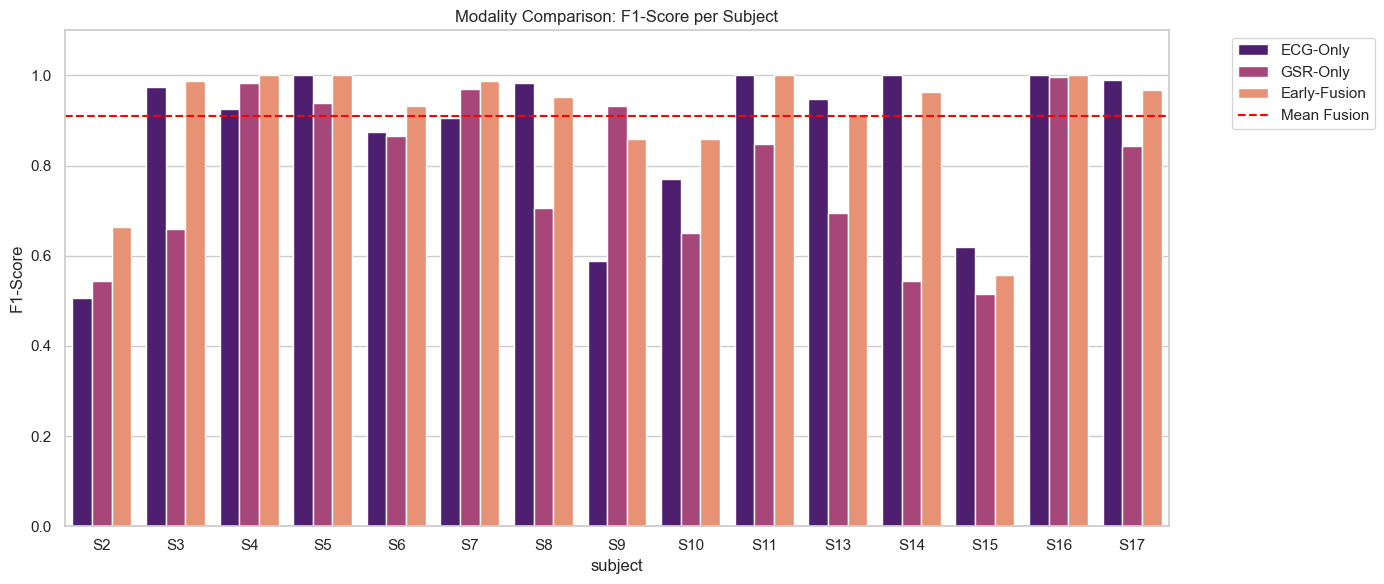

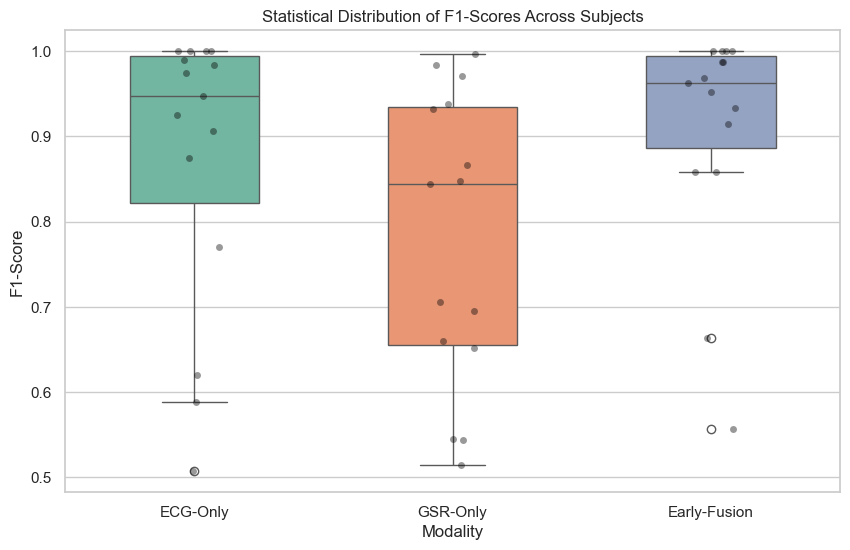

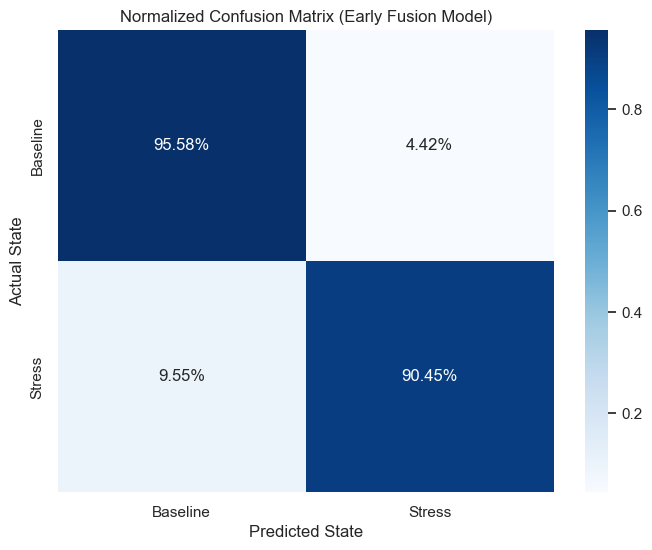

All results, models, and visualizations have been saved.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm
import pickle
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv('wesad_final_normalized_features.csv')

ecg_cols = [c for c in df.columns if 'HRV' in c or 'ECG_Rate' in c]
gsr_cols = [c for c in df.columns if 'SCR' in c or 'EDA' in c]
fusion_cols = ecg_cols + gsr_cols

# Classification targets
# 1=Baseline -> 0, 2=Stress -> 1
df['label_idx'] = df['label'].map({1: 0, 2: 1})
subjects = df['subject_id'].unique()

loso_results = []
all_actual = []
all_preds = []

print(f"Starting LOSO Cross-Validation on {len(subjects)} subjects...")

# LOSO loop
for test_sub in tqdm(subjects, desc="LOSO Iterations"):
    # Leave one subject out for testing
    train_df = df[df['subject_id'] != test_sub]
    test_df = df[df['subject_id'] == test_sub]
    
    y_train = train_df['label_idx']
    y_test = test_df['label_idx']
    
    sub_metrics = {'subject': test_sub}
    
    # Test 3 configs
    for name, cols in {
        'ECG-Only': ecg_cols, 
        'GSR-Only': gsr_cols, 
        'Early-Fusion': fusion_cols
    }.items():
        
        X_train = train_df[cols]
        X_test = test_df[cols]
        
        # XGBoost configuration for classification
        model = XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss'
        )
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        # individual metrics
        sub_metrics[f'{name}_Acc'] = accuracy_score(y_test, preds)
        sub_metrics[f'{name}_F1'] = f1_score(y_test, preds)
        
        # Fusion predictions for global confusion matrix
        if name == 'Early-Fusion':
            all_actual.extend(y_test.tolist())
            all_preds.extend(preds.tolist())
        
    loso_results.append(sub_metrics)

results_df = pd.DataFrame(loso_results)
results_df.to_csv('loso_detailed_results.csv', index=False)

# Train a final model on the full dataset
final_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
final_model.fit(df[fusion_cols], df['label_idx'])
with open('final_fusion_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

final_summary = results_df.mean(numeric_only=True)
print("\n--- Final Thesis Performance Summary ---")
print(final_summary)


sns.set_theme(style="whitegrid")

# Reshape data for plotting
plot_df = results_df.melt(id_vars='subject', 
                          value_vars=['ECG-Only_F1', 'GSR-Only_F1', 'Early-Fusion_F1'],
                          var_name='Modality', value_name='F1-Score')
plot_df['Modality'] = plot_df['Modality'].str.replace('_F1', '')

# Plot 1: Subject-wise Comparison (Bar Chart)
plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='subject', y='F1-Score', hue='Modality', palette='magma')
plt.axhline(results_df['Early-Fusion_F1'].mean(), color='red', linestyle='--', label='Mean Fusion')
plt.title('Modality Comparison: F1-Score per Subject')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('thesis_loso_bars.png')
plt.show()

# Plot 2: Performance Distribution (Box Plots)
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='Modality', y='F1-Score', palette='Set2', width=0.5)
sns.stripplot(data=plot_df, x='Modality', y='F1-Score', color='black', alpha=0.4, jitter=True)
plt.title('Statistical Distribution of F1-Scores Across Subjects')
plt.ylabel('F1-Score')
plt.savefig('thesis_loso_boxplots.png')
plt.show()

# Plot 3: Normalized Confusion Matrix (Heatmap)
cm_norm = confusion_matrix(all_actual, all_preds, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Baseline', 'Stress'], 
            yticklabels=['Baseline', 'Stress'])
plt.title('Normalized Confusion Matrix (Early Fusion Model)')
plt.ylabel('Actual State')
plt.xlabel('Predicted State')
plt.savefig('thesis_confusion_matrix.png')
plt.show()

print("All results, models, and visualizations have been saved.")